# 05 · The NY Fed Staff Nowcast: EM estimation with blocks

The Federal Reserve Bank of New York published a weekly *Staff Nowcast* of US GDP
(2016–2021) based on the model of Bańbura & Modugno (2014), described in Bok,
Caratelli, Giannone, Sbordone & Tambalotti (2018). Its ingredients:

* a **mixed-frequency** panel of ~25 headline indicators (monthly) plus GDP and unit
  labour costs (quarterly), linked by the Mariano & Murasawa (2003) restriction;
* **blocks**: a *global* factor loading on every series plus *real*, *labor* and
  *soft* (surveys) factors loading on subsets, so that, for instance, the two regional
  manufacturing surveys can share a common component of their own;
* **AR(1) idiosyncratic** components in the state vector;
* estimation by **maximum likelihood via EM** with arbitrary missing data
  (Shumway & Stoffer, 1982; Doz, Giannone & Reichlin, 2012; Bańbura & Modugno, 2014).

`load_nyfed()` ships the example specification and data file of the NY Fed's public
replication code (BSD-3 licence, vintage of 27 January 2017). As the NY Fed itself
notes, these example files do not exactly reproduce the published nowcasts; we
replicate the **model**, not the published numbers.

In [1]:
import sys
import time
from pathlib import Path

HERE = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
sys.path.insert(0, str(HERE.parent))

import pandas as pd
from utils import display, md, setup, show

import nowcastbox as nb

setup()

## 1. The specification

In [2]:
ds = nb.load_nyfed()
print(ds.summary())
display(ds.legend[["description", "frequency", "transform", "blocks", "category"]])

Dataset 'nyfed': NY Fed Staff Nowcast replication panel (US)
  Sample        : 1985-01 to 2017-01 (385 months)
  Series        : 25 (M: 23, Q: 2)
  Categories    : hard: 23, soft: 2
  Blocks        : global, labor, real, soft
  Target        : GDPC1
  License       : Repository files: BSD 3-Clause License, Copyright (c) 2018, Federal Reserve Bank of New York (redistribution with this notice). Underlying series: FRED, from US government agencies and regional Federal Reserve Banks.
  Sources       : https://github.com/FRBNY-TimeSeriesAnalysis/Nowcasting - Spec_US_example.xls and data/US/2017-01-27.xls (data downloaded by the NY Fed from FRED, Federal Reserve Bank of St. Louis)


,description,frequency,transform,blocks,category
series,,,,,
PAYEMS,Payroll Employment,M,diff,global;labor,hard
JTSJOL,Job Openings,M,diff,global;labor,hard
GDPC1,Real Gross Domestic Product,Q,log|diff(1)|scale(400),global;real,hard
CPIAUCSL,Consumer Price Index,M,pct_change(1)|scale(100),global,hard
DGORDER,Durable Goods Orders,M,pct_change(1)|scale(100),global;real,hard
RSAFS,Retail Sales,M,pct_change(1)|scale(100),global;real,hard
UNRATE,Unemployment Rate,M,diff,global;labor,hard
HOUST,Housing Starts,M,pct_change(1)|scale(100),global;real,hard
INDPRO,Industrial Production,M,pct_change(1)|scale(100),global;real,hard


In [3]:
display(ds.blocks.astype(int).sum().rename("series per block").to_frame())

,series per block
global,25
labor,4
real,13
soft,2


Monthly growth rates enter in per cent, GDP as an annualised quarterly log-difference
(`log|diff(1)|scale(400)`) — so the nowcast is in the familiar "% SAAR" units of the
US national accounts. Following the NY Fed, the panel is **not** cleaned: no outlier
replacement and no filling of missing values (the EM handles them), and series are
never dropped for being short (JOLTS openings start in 2000).

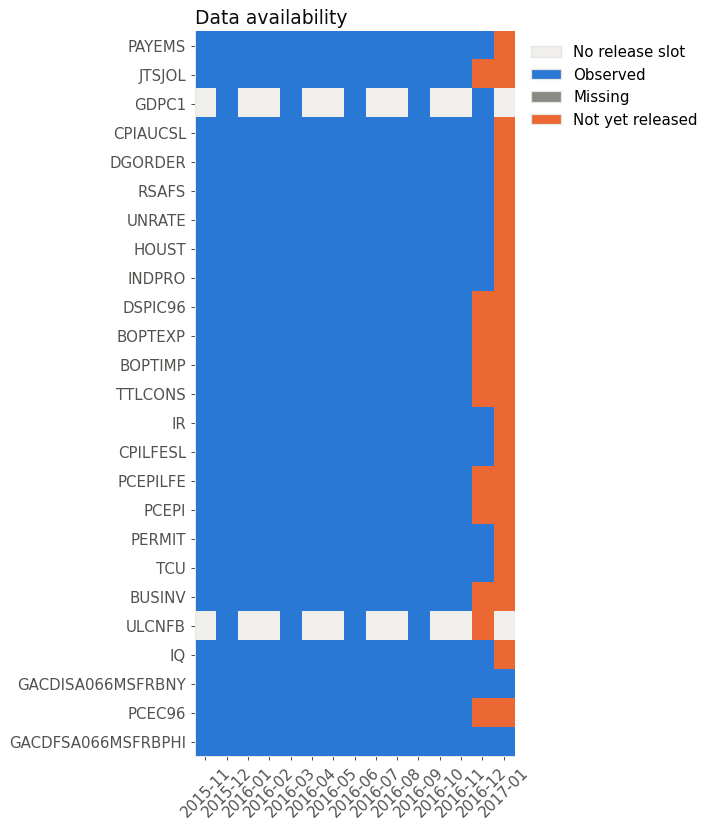

In [4]:
panel = nb.prepare_panel(
    ds.data, ds.transform, replace_outliers=False, replace_na=False, max_na_prop=1.0
)
fig = nb.visualization.plot_data_availability(panel, n_periods=15, backend="matplotlib")
show(fig, "05_ragged_edge")

## 2. Estimation

One factor per block (`n_factors=1`), a VAR(1) for the factors, `blocks="data"` (use
the block membership stored in the panel metadata), AR(1) idiosyncratic terms. The EM
runs until the relative change of the log-likelihood falls below `tol = 1e-4`, the
NY Fed's default.

In [5]:
start = time.perf_counter()
model = nb.MixedFreqDFM(n_factors=1, factor_lags=1, blocks="data", max_iter=500, tol=1e-4)
res = model.fit(panel, target="GDPC1")
elapsed = time.perf_counter() - start
print(res.summary())
md(f"EM converged in **{res.n_iter} iterations** and **{elapsed:.1f} s**.")

                        Nowcast Results: MixedFreqDFM
Target:                 GDPC1 (quarterly)
Sample:                 1985-01 .. 2017-01
Series:                 25
Factors:                4
Log-likelihood:         -9003.0014
Iterations:             40
Converged:              True
------------------------------------------------------------------------------
Model parameters
  n_factors             1
  factor_lags           1
  blocks                data
  idiosyncratic         ar1
  max_iter              500
  tol                   0.0001
  init                  pca
  obs_noise_var         0.0001
  filter_method         auto
  df                    -
  outliers              none
  outlier_threshold     4.0000
  exclude_periods       -
  covid                 none
  covid_window          ('2020-03', '2021-12')
  long_run_mean         constant
  long_run_series       -
  long_run_variance     -
------------------------------------------------------------------------------
Factor dynami

EM converged in **40 iterations** and **2.7 s**.

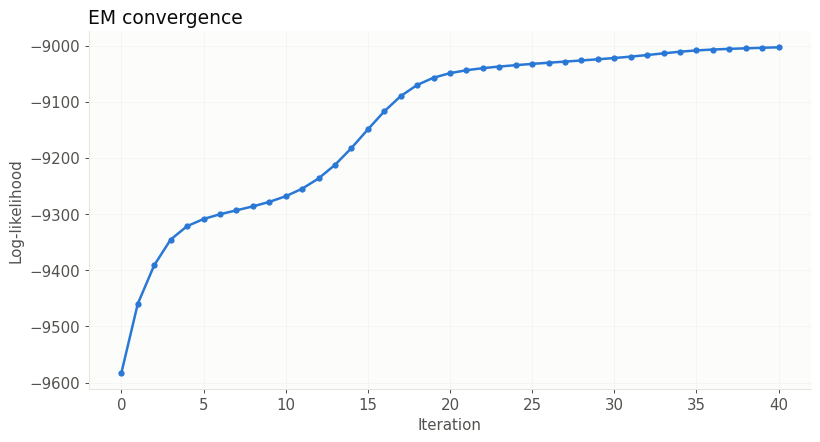

In [6]:
fig = res.plot("loglikelihood", backend="matplotlib")
show(fig, "05_loglik")

The log-likelihood increases monotonically and flattens after a dozen iterations —
the usual EM behaviour: big gains early, slow linear convergence later.

## 3. Factors and loadings

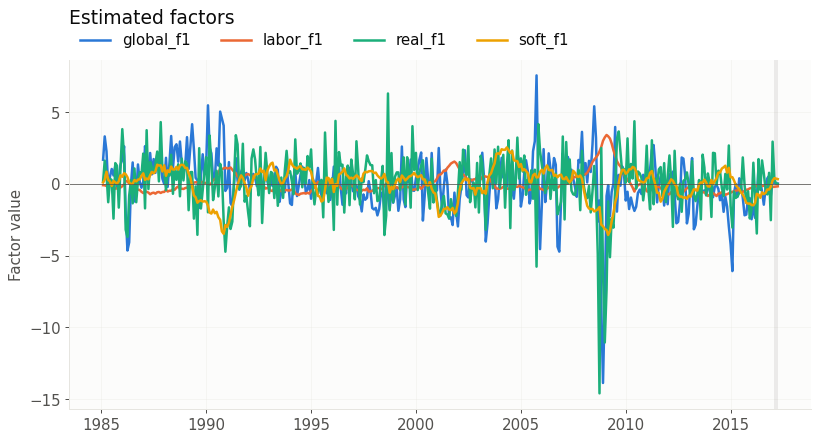

In [7]:
fig = res.plot("factors", backend="matplotlib")
show(fig, "05_factors")

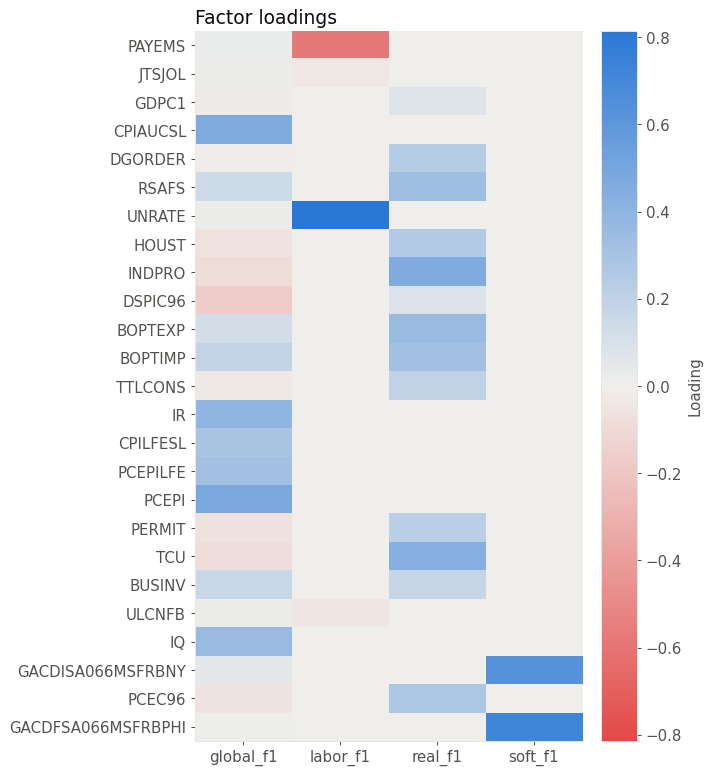

In [8]:
fig = res.plot("loadings", backend="matplotlib")
show(fig, "05_loadings")

The **global** factor is the business cycle (deep trough in 2008–2009) and loads on
almost everything; the **soft** factor captures what the Empire State and Philadelphia
Fed surveys share beyond the global cycle; the **labor** factor separates payrolls,
unemployment and job openings from output-side data; prices load mostly on the global
factor with small weights — the NY Fed found that nominal data carry little
information for real GDP.

## 4. The nowcast

In [9]:
display(res.nowcast[["observed", "in_sample", "out_of_sample", "lower_68", "upper_68"]].tail(6))
md(
    f"Nowcast of US real GDP growth for **2017Q1** with the data of 27 January 2017: "
    f"**{res.get_nowcast('2017Q1'):.2f} % SAAR**. The fourth quarter of 2016 (advance "
    f"estimate published that same day) had grown {res.observed.loc['2016Q4']:.2f} %."
)

,observed,in_sample,out_of_sample,lower_68,upper_68
period,,,,,
2015Q4,0.8693,1.1574,NaN,NaN,NaN
2016Q1,0.8311,1.9852,NaN,NaN,NaN
2016Q2,1.4039,2.2835,NaN,NaN,NaN
2016Q3,3.4560,3.3954,NaN,NaN,NaN
2016Q4,1.8562,2.2251,NaN,NaN,NaN
2017Q1,NaN,NaN,3.2555,0.9928,5.5182


Nowcast of US real GDP growth for **2017Q1** with the data of 27 January 2017: **3.26 % SAAR**. The fourth quarter of 2016 (advance estimate published that same day) had grown 1.86 %.

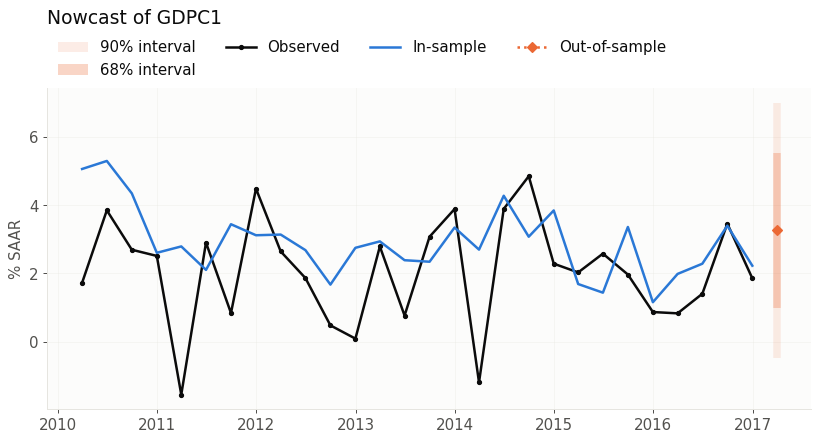

In [10]:
fig = res.plot("forecast", backend="matplotlib", start="2010Q1", ylabel="% SAAR")
show(fig, "05_forecast")

## 5. A weekly update and its *news*

The NY Fed Staff Nowcast was updated every Friday, and each update was explained by
the **news** of the releases of the week: the difference between each released value
and the model's expectation of it, times a weight (Bańbura & Modugno, 2014). We
rebuild two pseudo real-time vintages two weeks apart (stylised publication delays)
and decompose the revision of the 2017Q1 nowcast. Notebook 07 develops the method.

In [11]:
old = nb.pseudo_real_time(panel, vintage="2017-01-13")
new = nb.pseudo_real_time(panel, vintage="2017-01-27")
res_new = model.fit(new, target="GDPC1")
news = res_new.news(old, new, target_period="2017Q1")
print(news.summary())

News decomposition: GDPC1 2017Q1 (MixedFreqDFM)
  Old nowcast                     2.121597
  Data revisions                  0.000000
  News (new releases)             1.191588
  Re-estimation                   0.000000
  New nowcast                     3.313185
  Releases / revised             10 / 0
------------------------------------------------------------------------------
  category                            news     revisions         total
  hard                            1.191588      0.000000      1.191588
------------------------------------------------------------------------------
  release                         actual    expected      weight      impact
  INDPRO 2016-12                  0.8298     -0.0718      0.9821      0.8855
  TCU 2016-12                     0.6000     -0.0713      0.5368      0.3604
  CPIAUCSL 2016-12                0.2822      0.1741     -0.4490     -0.0486
  HOUST 2016-12                  11.2523      4.2102      0.0025      0.0174
  IR 2016-12

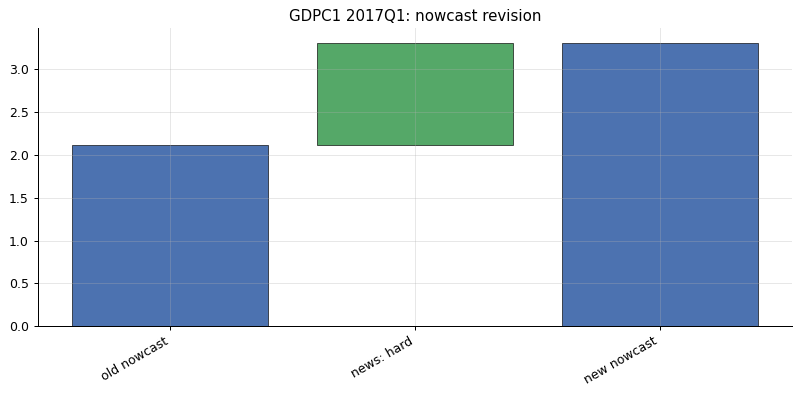

In [12]:
fig = news.plot("waterfall")
show(fig, "05_news")

In [13]:
releases = news.releases.set_index("series")
ip_tcu = float(releases.loc[["INDPRO", "TCU"], "impact"].sum())
md(
    f"December industrial production and capacity utilisation surprised on the upside "
    f"relative to what the model expected given earlier data, and they carry large "
    f"weights: together they move the nowcast by **{ip_tcu:+.2f} percentage points** of "
    f"the {news.news_effect:+.2f} total news. Housing starts were a large surprise in "
    f"per cent terms but have a small weight "
    f"({releases.loc['HOUST', 'weight']:.4f}) — they are noisy, so the model discounts "
    "them. This is precisely the \"news\" narrative of the NY Fed's weekly reports."
)

December industrial production and capacity utilisation surprised on the upside relative to what the model expected given earlier data, and they carry large weights: together they move the nowcast by **+1.25 percentage points** of the +1.19 total news. Housing starts were a large surprise in per cent terms but have a small weight (0.0025) — they are noisy, so the model discounts them. This is precisely the "news" narrative of the NY Fed's weekly reports.

## 6. Speed: the structured E-step (innovation I2)

By default `MixedFreqDFM(filter_method="auto")` uses an exact *structured* smoother
that exploits the block-diagonal structure of the idiosyncratic states. On a model of
this size (N = 25) the dense univariate Kalman smoother is just as fast; the gains
appear with large panels (≈ 12× per EM iteration at N = 200 versus statsmodels'
`DynamicFactorMQ`, see notebook 15 and `benchmarks/bench_em.py`). The estimates are
identical up to floating-point error:

In [14]:
timings = {}
nowcasts = {}
for method in ("auto", "univariate"):
    t0 = time.perf_counter()
    fit = nb.MixedFreqDFM(n_factors=1, factor_lags=1, blocks="data", filter_method=method).fit(
        panel, target="GDPC1"
    )
    timings[method] = time.perf_counter() - t0
    nowcasts[method] = fit.get_nowcast("2017Q1")
display(pd.DataFrame({"seconds": timings, "nowcast 2017Q1": nowcasts}))

,seconds,nowcast 2017Q1
auto,2.7086,3.2555
univariate,2.7803,3.2555


### References

* Bańbura, M. & Modugno, M. (2014). Maximum likelihood estimation of factor models on
  datasets with arbitrary pattern of missing data. *Journal of Applied Econometrics*,
  29(1), 133–160.
* Bok, B., Caratelli, D., Giannone, D., Sbordone, A. M. & Tambalotti, A. (2018).
  Macroeconomic nowcasting and forecasting with big data. *Annual Review of
  Economics*, 10, 615–643.
* Doz, C., Giannone, D. & Reichlin, L. (2012). A quasi-maximum likelihood approach
  for large, approximate dynamic factor models. *REStat*, 94(4), 1014–1024.
* Mariano, R. S. & Murasawa, Y. (2003). *Journal of Applied Econometrics*, 18(4),
  427–443.
* Shumway, R. H. & Stoffer, D. S. (1982). An approach to time series smoothing and
  forecasting using the EM algorithm. *Journal of Time Series Analysis*, 3(4),
  253–264.